In [1]:
import matplotlib.pyplot as plt
import pandas as pd

dataset = pd.read_parquet("renewables-dataset.parquet")
dataset["Time"] = pd.to_datetime(dataset["Time"])
print(dataset.head())



                       Time ID  demand_MWh  supply_MWh  solar_MWh   wind_MWh  \
0 2012-01-01 00:00:00+00:00  1     75.6549    9.150821        0.0  18.301642   
1 2012-01-01 00:00:00+00:00  2    557.8868    6.196411        0.0  12.392822   
2 2012-01-01 00:00:00+00:00  3     15.5237    6.855084        0.0  13.710167   
3 2012-01-01 00:00:00+00:00  4      8.6425    7.824092        0.0  15.648183   
4 2012-01-01 00:00:00+00:00  5     85.3649    2.053690        0.0   4.107380   

   solar_rel_prod  wind_rel_prod   latitude  longitude country  \
0             0.0         0.0284  42.094674  -8.113982     POR   
1             0.0         0.0103  41.587435  -8.326462     POR   
2             0.0         0.0283  41.585994  -6.722728     POR   
3             0.0         0.0408  41.597684  -6.342848     POR   
4             0.0         0.0092  41.373957  -7.350949     POR   

   solar_layout_MW  wind_layout_MW  
0         982.8607        644.4240  
1        1361.0601       1203.1866  
2         7

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

dataset = dataset[["Time", "country", "demand_MWh"]]
dataset = dataset.set_index("Time")

countries = dataset["country"].unique()

results_dict = {}

for country in countries:
    print(country)
    country_df = dataset[dataset["country"] == country].copy()
    country_df = country_df.drop(columns=["country"])

    country_df = country_df.groupby(country_df.index).sum()

    mean = np.mean(country_df["demand_MWh"])
    std = np.std(country_df["demand_MWh"])
    country_df["demand_MWh"] = (country_df["demand_MWh"] - mean) / std
    

    country_df["hour"] = country_df.index.hour
    country_df["day_of_week"] = country_df.index.day_of_week
    country_df["month"] = country_df.index.month
    
    
    reg_df = pd.get_dummies(country_df, columns=["day_of_week"], prefix="day_of_week", drop_first=False)
    reg_df = pd.get_dummies(reg_df, columns=["month"], prefix="month", drop_first=False)
    
 
    X = reg_df.to_numpy()[:, 1:].astype(float)
    y = reg_df.to_numpy()[:, 0].astype(float)
    
   
    model = sm.OLS(y, X)
    res = model.fit()
    
  
    results_dict[country] = {
        "params": res.params,
        "pvalues": res.pvalues,
        "rsquared": res.rsquared,
    }




POR
ESP
FRA
BEL
CHE
LUX
NLD
ITA
DEU
AUT
DNK
CZE
POL
HUN
SVK
SVN
HRV
GRC
ALB
MKD
BGR
MNE
BIH
SRB
ROU


In [3]:
params_df = pd.DataFrame({
    country: results_dict[country]["params"]
    for country in countries
}).T  

print(params_df.head())

           0         1         2         3         4         5         6   \
POR  0.086377 -0.512293 -0.368119 -0.337492 -0.342668 -0.373226 -1.051125   
ESP  0.065652 -0.340305 -0.176997 -0.168563 -0.189859 -0.254706 -0.884032   
FRA  0.028077 -0.126712 -0.004710  0.011131 -0.003330 -0.050866 -0.500022   
BEL  0.054899 -0.293945 -0.104116 -0.069880 -0.079325 -0.157788 -0.878437   
CHE  0.015024  0.044405  0.141387  0.126487  0.102613  0.041139 -0.495585   

           7         8         9         10        11        12        13  \
POR -1.393802  0.166544  0.229104 -0.300009 -0.634353 -0.724545 -0.634235   
ESP -1.309509  0.144216  0.350486 -0.213704 -0.602159 -0.670431 -0.393761   
FRA -0.720899  0.973155  1.289509  0.351029 -0.208269 -0.718580 -0.846528   
BEL -1.187682  0.428018  0.574743  0.082067 -0.325838 -0.628971 -0.619955   
CHE -0.694297  0.976763  1.249500  0.550518 -0.283089 -0.896582 -0.756907   

           14        15        16        17        18        19  
POR -0.3

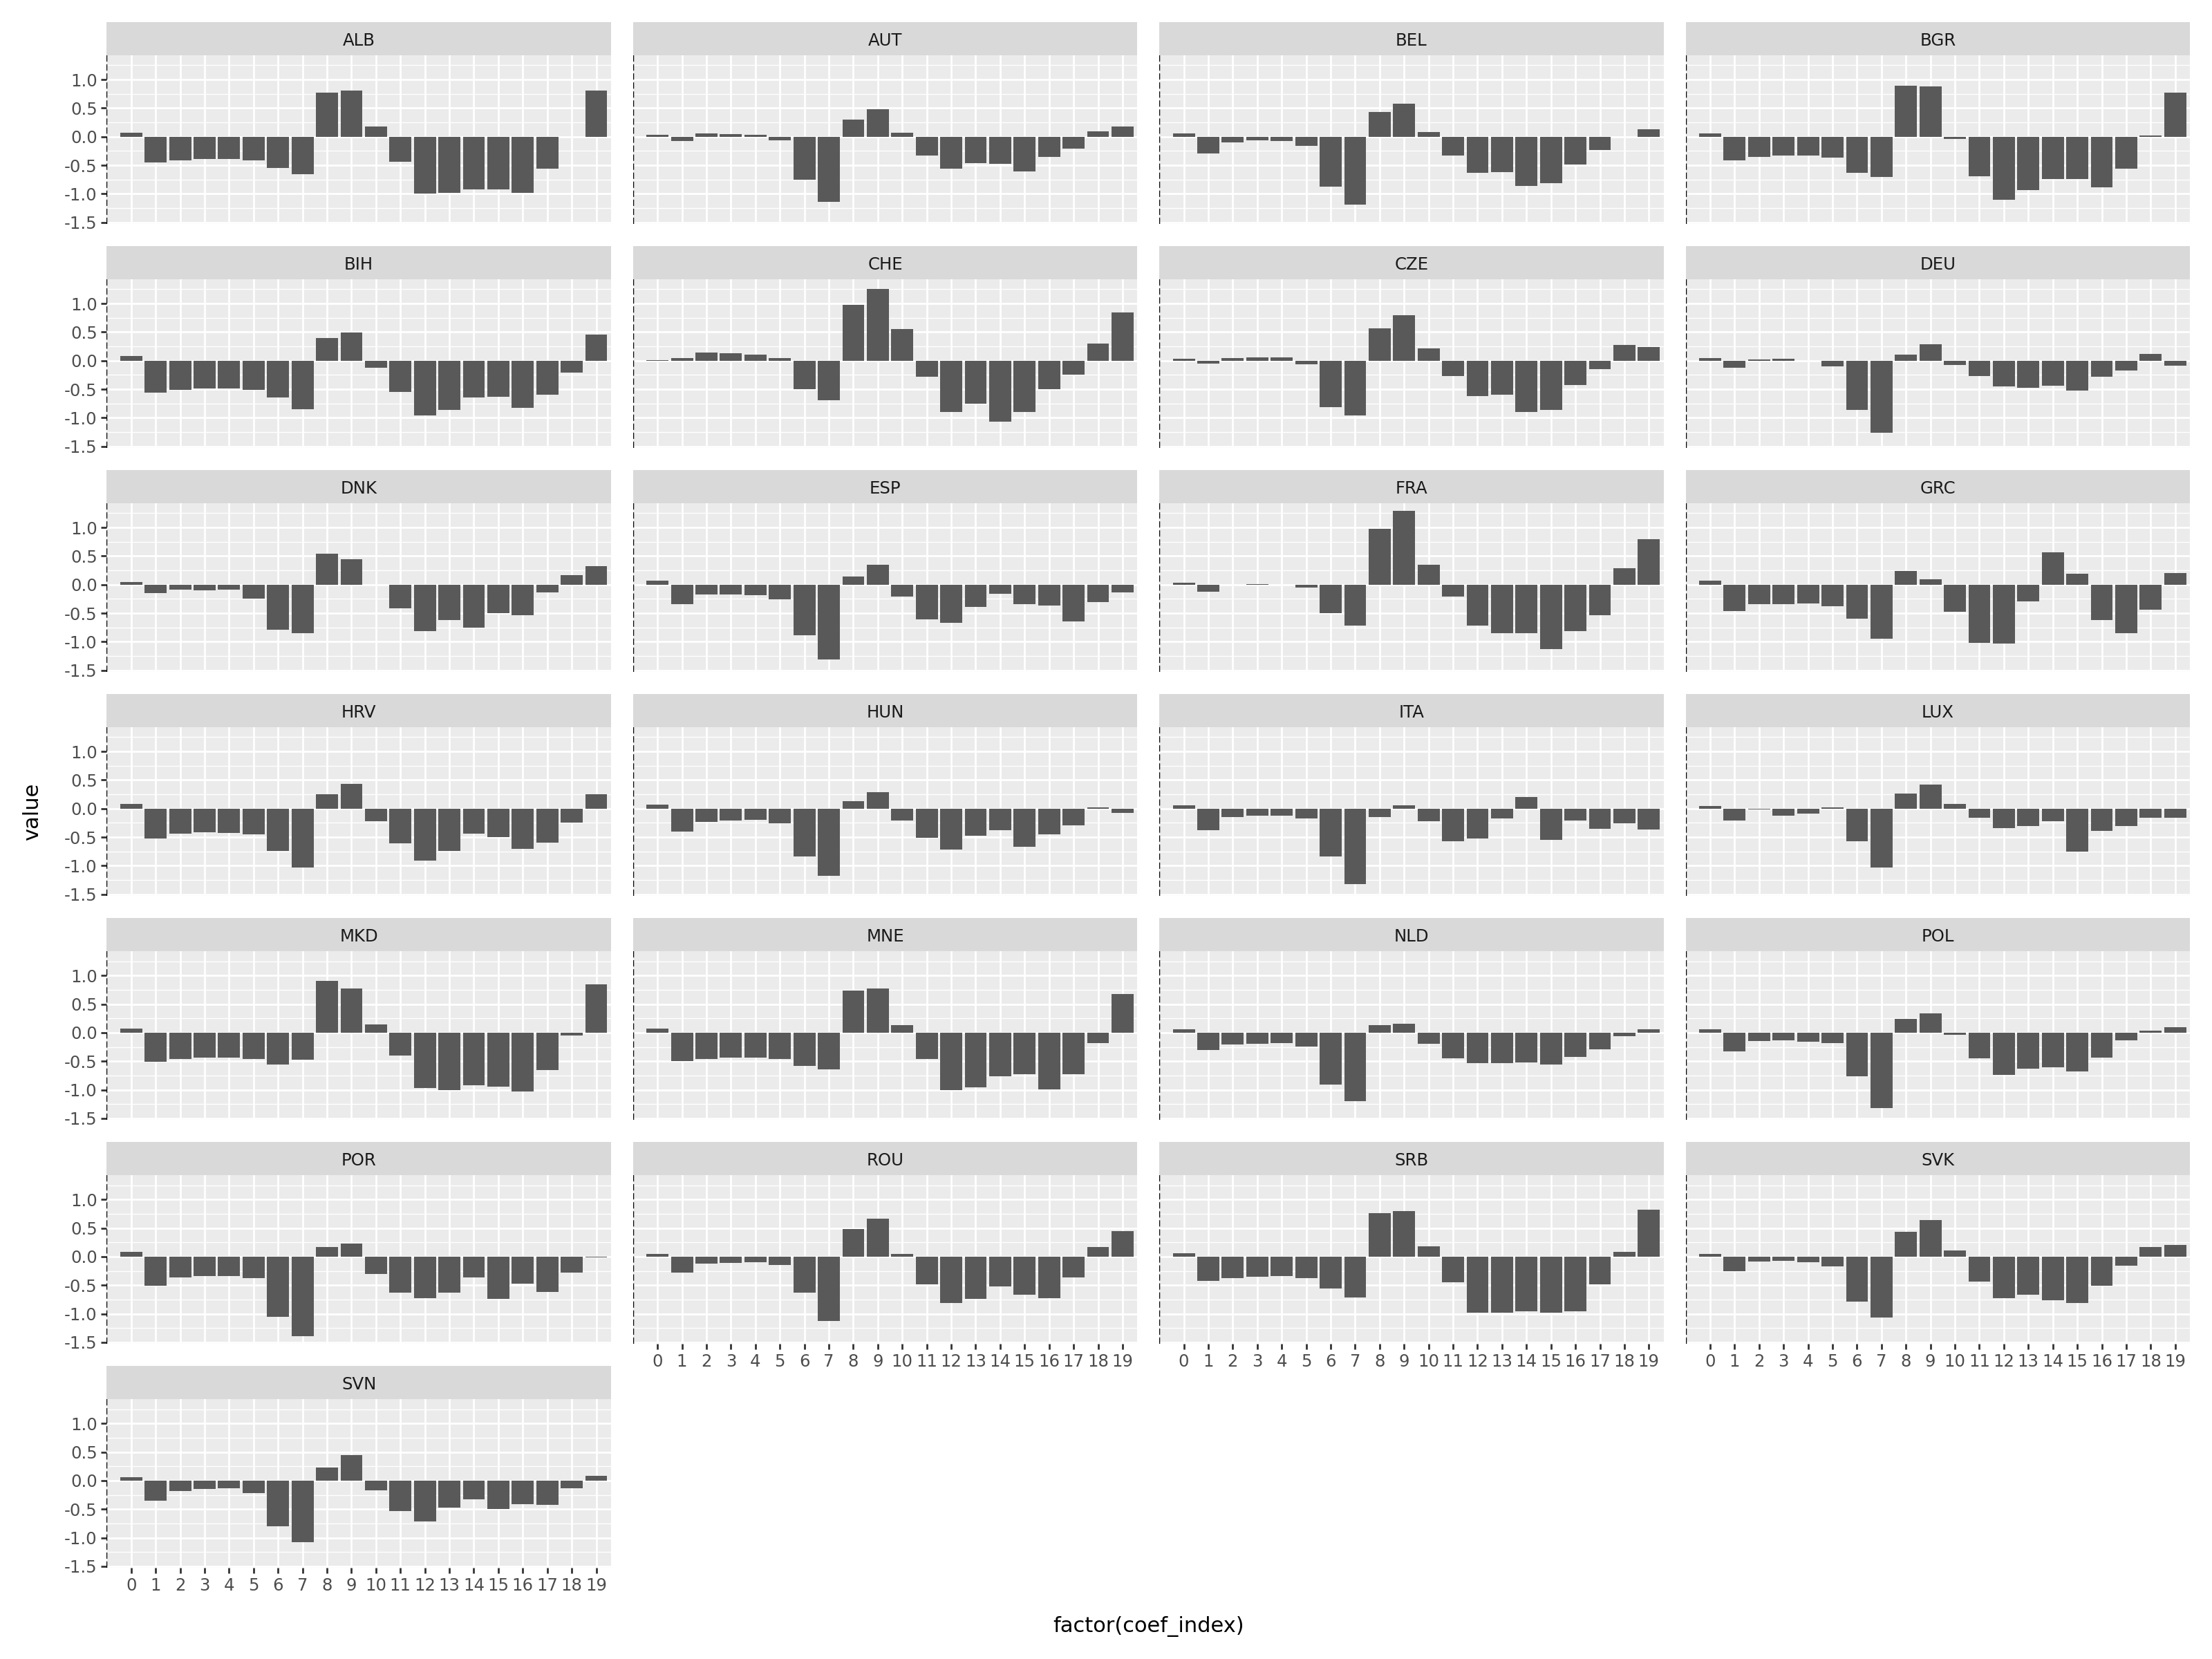

In [4]:
coef_df = params_df.reset_index().melt(
    id_vars="index",
    var_name="coef_index",
    value_name="value"
)


coef_df = coef_df.rename(columns={"index": "country"})


from plotnine import ggplot, aes, geom_col, facet_wrap, geom_vline, theme

(
    ggplot(coef_df, aes(y="value", x="factor(coef_index)"))
    + geom_col()
    + geom_vline(xintercept=0, linetype="dashed")
    + facet_wrap("~country", ncol=4)
    + theme(figure_size=(16, 12))  
)

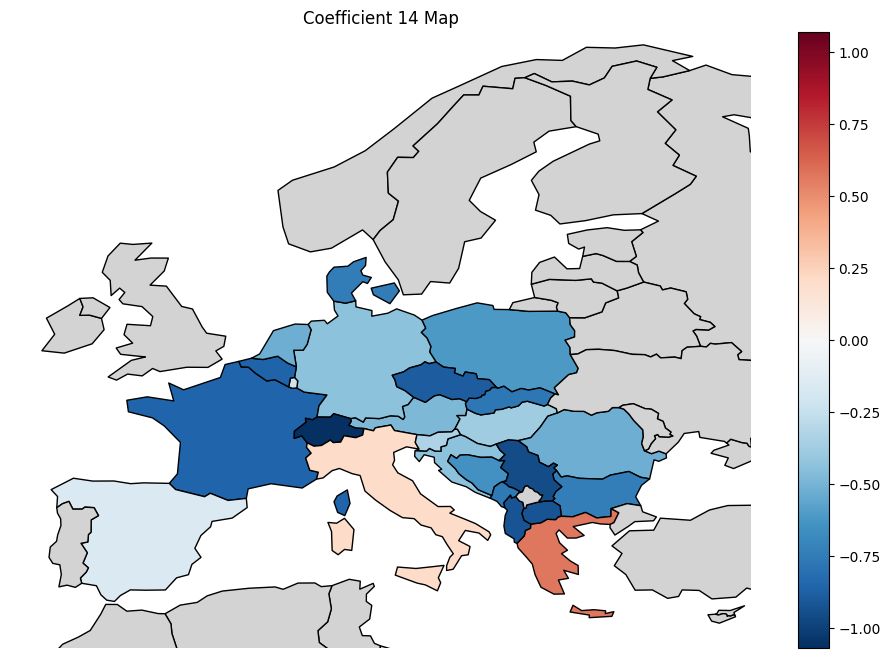

In [34]:
import geopandas as gpd
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap

colors = [
    "#053061", "#2166ac", "#4393c3", "#92c5de", "#d1e5f0",
    "#f7f7f7",
    "#fddbc7", "#f4a582", "#d6604d", "#b2182b", "#67001f"
]

cmap = LinearSegmentedColormap.from_list("custom_diverging", colors)

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)


coefficient=14
coef_series = params_df[coefficient]

df = coef_series.reset_index()
df.columns = ["iso_a3", "value"]

merged = world.merge(df, left_on="ADM0_A3", right_on="iso_a3", how="left")

fig, ax = plt.subplots(figsize=(12, 8))

vmax = abs(merged["value"]).max()

merged.plot(
    column="value",
    cmap=cmap,
    #vmin=-vmax,
    edgecolor= "black",
    vmax=vmax,
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_xlim(-12, 35)
ax.set_ylim(33, 72)

ax.set_title(f"Coefficient {coefficient} Map")
ax.axis("off")

plt.show()